<a href="https://colab.research.google.com/github/aerau05/ds3001proj/blob/genomics-lab/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
''' 1. Load golub dataset and relabel target variable'''

import pandas as pd

df = pd.read_csv('golub.csv', header=None)

# Drop header row (row 0)
df = df.iloc[1:, :]

# Extract labels
labels = df.iloc[:, 5].astype(str).str.upper()

# Features (genes)
X = df.iloc[:, 6:].astype(float)

# Binary target: ALL family = 0, AML = 1
y = labels.replace({
    'ALL': 0,
    'ALLB': 0,
    'ALLT': 0,
    'AML': 1
}).astype(int)

# Check everything
print("X shape:", X.shape)
print("y counts:\n", y.value_counts())

X shape: (72, 7129)
y counts:
 5
0    47
1    25
Name: count, dtype: int64


/var/folders/lb/xyzsk4h57k33hzb7w0x12_xw0000gn/T/ipykernel_26445/560207962.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = labels.replace({


MSE: 3.696244749267983e-30


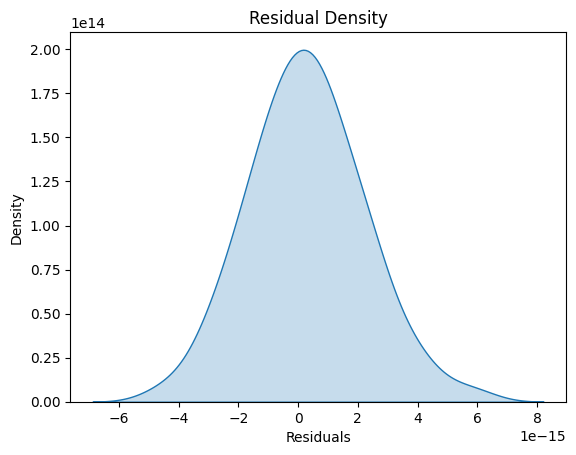

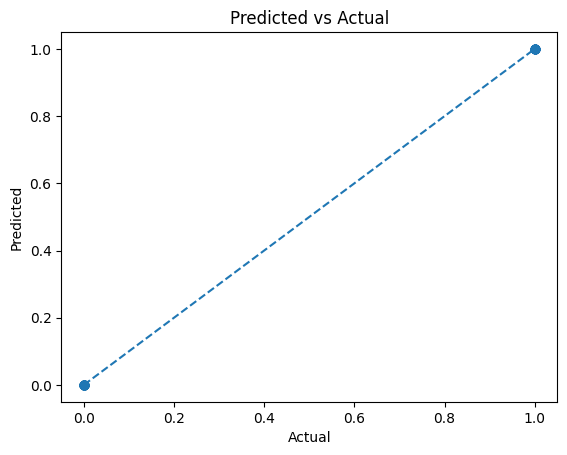

In [12]:
'''2. Linear Regression, MSE, kernal density plot, and scatter plot'''
# Fit model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# Mean Squared Error
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

# Residuals
residuals = y - y_pred

# Kernel Density Plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(residuals, fill=True)
plt.title("Residual Density")
plt.xlabel("Residuals")
plt.show()

# Predicted vs Actual Scatterplot
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

# reference line
plt.plot([0, 1], [0, 1], linestyle='--')
plt.show()


In [13]:
'''3. Cross-validation for Linear Regression'''

from sklearn.model_selection import KFold, cross_val_score
import numpy as np

# Initialize model (same as before)
model = LinearRegression()

# K-Fold setup (5-fold is good for small datasets)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
mse_scores = -cross_val_score(model, X, y, 
                             scoring='neg_mean_squared_error', 
                             cv=kf)

# Print results
print("Cross-Validation MSE (each fold):", mse_scores)
print("Average CV MSE:", np.mean(mse_scores))
print("Std Dev of CV MSE:", np.std(mse_scores))

Cross-Validation MSE (each fold): [0.04538415 0.04291022 0.04477968 0.04690803 0.02421453]
Average CV MSE: 0.040839321235969755
Std Dev of CV MSE: 0.008410508351139125


### Results/Analysis
Cross-validation using 5-fold validation produced mean squared errors ranging from 0.024 to 0.047, with an average of 0.0408 and a standard deviation of 0.0084. The variation across folds indicates some sensitivity to the training data, suggesting moderate variance in the model. Since the cross-validation error is higher than the training error, this implies the model is overfitting. From a bias-variance perspective, the linear regression model has low bias but relatively high variance, which is expected given the high-dimensional nature of the dataset (thousands of gene features but only 72 samples), reflecting the challenges of high-dimensional data.